# Supply Chain & Demand Planning — Exploratory Analysis

This notebook explores the analytics-ready datasets produced by the pipeline
(`python src/run_all.py`). It surfaces the demand patterns, seasonality and
inventory signals that drive the dashboards and the forecasting model.

**Prereq:** run `python src/run_all.py` first so `data/processed/` is populated.

In [1]:
import sys, sqlite3
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent / 'src'))
from config import DB_PATH, PROCESSED_DIR
sns.set_theme(style='whitegrid')
pd.options.display.float_format = '{:,.2f}'.format

In [2]:
conn = sqlite3.connect(DB_PATH)
sales = pd.read_sql('SELECT date_key, category, channel, quantity, revenue, gross_margin FROM fact_sales', conn, parse_dates=['date_key'])
conn.close()
print(f'{len(sales):,} sales transactions | {sales.date_key.min().date()} to {sales.date_key.max().date()}')
sales.head()

519,351 sales transactions | 2022-01-01 to 2024-12-31


,date_key,category,channel,quantity,revenue,gross_margin
0,2022-01-01,Sports & Outdoors,E-Commerce,1,99.78,42.42
1,2022-01-01,Electronics,Retail Store,10,"1,994.90",595.40
2,2022-01-01,Home & Kitchen,E-Commerce,1,51.89,22.18
3,2022-01-01,Home & Kitchen,Retail Store,2,151.60,56.00
4,2022-01-01,Electronics,Wholesale,6,"1,200.90",259.68


## 1. Revenue trend & seasonality

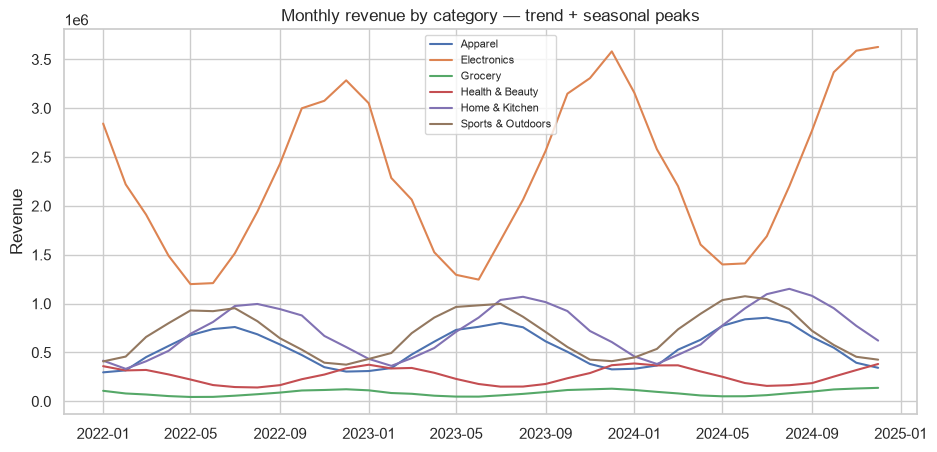

In [3]:
monthly = sales.set_index('date_key').groupby('category').resample('MS')['revenue'].sum().reset_index()
fig, ax = plt.subplots(figsize=(11,5))
for cat, g in monthly.groupby('category'):
    ax.plot(g['date_key'], g['revenue'], label=cat)
ax.set_title('Monthly revenue by category — trend + seasonal peaks')
ax.set_ylabel('Revenue'); ax.legend(fontsize=8); plt.show()

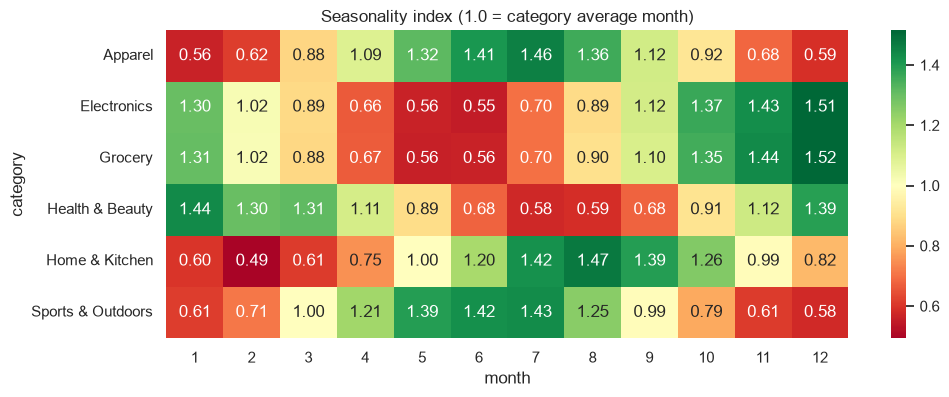

In [4]:
# Seasonality heat-grid: average units by month x category
sales['month'] = sales['date_key'].dt.month
pivot = sales.pivot_table(index='category', columns='month', values='quantity', aggfunc='sum')
pivot = pivot.div(pivot.mean(axis=1), axis=0)  # index vs each category's own mean
plt.figure(figsize=(11,4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=1.0)
plt.title('Seasonality index (1.0 = category average month)'); plt.show()

## 2. Channel mix & weekday effect

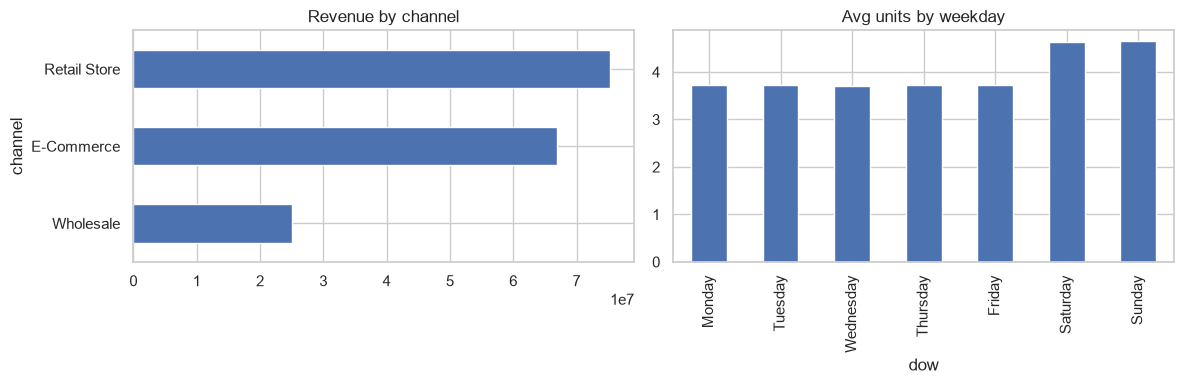

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sales.groupby('channel')['revenue'].sum().sort_values().plot.barh(ax=axes[0], title='Revenue by channel')
sales['dow'] = sales['date_key'].dt.day_name()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sales.groupby('dow')['quantity'].mean().reindex(order).plot.bar(ax=axes[1], title='Avg units by weekday')
plt.tight_layout(); plt.show()

## 3. ABC inventory classification

In [6]:
abc = pd.read_csv(PROCESSED_DIR / 'inventory_abc.csv')
summary = abc.groupby('abc_class').agg(skus=('product_id','count'), revenue=('annual_revenue','sum'), inv_value=('inventory_value','sum'))
summary['revenue_%'] = (summary['revenue']/summary['revenue'].sum()*100).round(1)
summary['skus_%'] = (summary['skus']/summary['skus'].sum()*100).round(1)
summary

,skus,revenue,inv_value,revenue_%,skus_%
abc_class,,,,,
A,213,"47,258,809.92","2,828,015.91",79.90,35.50
B,178,"8,938,708.14","716,032.78",15.10,29.70
C,209,"2,963,191.62","289,149.52",5.00,34.80


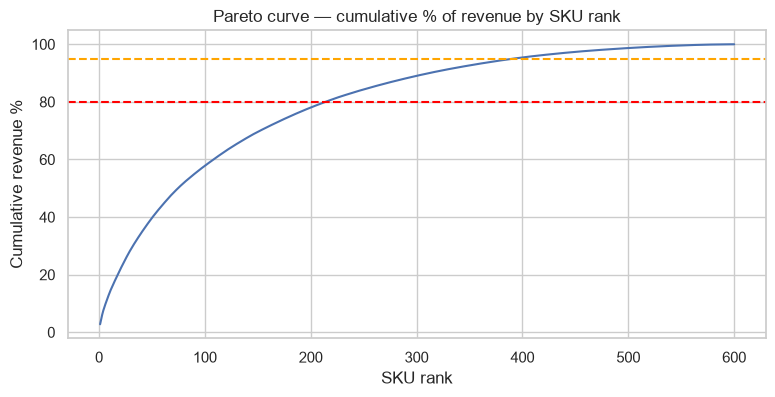

In [7]:
# Pareto curve
abc_sorted = abc.sort_values('annual_revenue', ascending=False).reset_index(drop=True)
cum = abc_sorted['annual_revenue'].cumsum()/abc_sorted['annual_revenue'].sum()*100
plt.figure(figsize=(9,4))
plt.plot(range(1,len(cum)+1), cum)
plt.axhline(80, color='red', ls='--'); plt.axhline(95, color='orange', ls='--')
plt.title('Pareto curve — cumulative % of revenue by SKU rank')
plt.xlabel('SKU rank'); plt.ylabel('Cumulative revenue %'); plt.show()

## 4. Forecast accuracy: ML vs baseline

                     model  MAPE  WAPE
 Moving-Average (baseline) 19.91 11.09
Seasonal-Naive (reference) 15.64  8.40
    Gradient Boosting (ML) 15.08  6.60


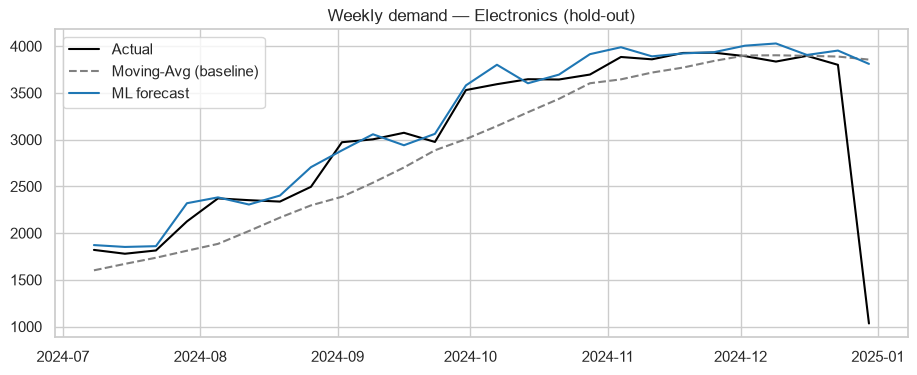

In [8]:
fc = pd.read_csv(Path.cwd().parent / 'reports' / 'forecast_accuracy_summary.csv')
all_rows = fc[fc['category']=='ALL'][['model','MAPE','WAPE']]
print(all_rows.to_string(index=False))
fva = pd.read_csv(PROCESSED_DIR / 'forecast_vs_actual.csv', parse_dates=['week'])
cat = 'Electronics'
sub = fva[fva['category']==cat]
plt.figure(figsize=(11,4))
plt.plot(sub['week'], sub['actual'], label='Actual', color='black')
plt.plot(sub['week'], sub['baseline_forecast'], label='Moving-Avg (baseline)', ls='--', color='gray')
plt.plot(sub['week'], sub['ml_forecast'], label='ML forecast', color='tab:blue')
plt.title(f'Weekly demand — {cat} (hold-out)'); plt.legend(); plt.show()